In [5]:
import torch
from mpmath import mpf
from mpmath import mp
import mpmath
import simulation_2MQRM as t
import numpy as np
import qutip as qt
import scipy as sp
from scipy import special as spsp
import math
import matplotlib.pyplot as plt
import matplotlib
import colorcet as cc
from scipy.optimize import newton
mp.dps = 20
print(mp)

Mpmath settings:
  mp.prec = 70                [default: 53]
  mp.dps = 20                 [default: 15]
  mp.trap_complex = False     [default: False]


In [6]:
def mode_eigs_wishart(Dg, De, normalised, beta=2, c=1.0):
    M = np.min([Dg,De])
    N = np.max([Dg,De])
    
    if N==M:
        z=np.array([0.0])
        z_lag, _ = sp.special.roots_genlaguerre(M-1, 1.0)
        z = np.concatenate(([0.0], z_lag))
    else:
        alpha = N - M - 1
        z, _ = sp.special.roots_genlaguerre(M,alpha)
    
    roots_sorted = np.flip(np.sort(z))
    if normalised ==True:
        lambdas_mode = roots_sorted / roots_sorted[0]
        return lambdas_mode
    elif normalised==False:
        lambdas_mode = roots_sorted
        return lambdas_mode

def mode_eigs_wishart_mpmath(Dg, De, normalised=True, beta=2, c=1.0, dps=50):
    mp.dps = dps

    M = int(min(Dg, De))
    N = int(max(Dg, De))

    def laguerre_roots(n, alpha):
        """Zeros of L_n^{(alpha)}(x) via Golub–Welsch (mpmath version)."""
        if n <= 0:
            return []

        # Jacobi matrix for generalized Laguerre polynomials
        # Diagonal: 2k + alpha + 1,  k = 0..n-1
        # Off-diagonal: sqrt((k+1)*(k+alpha+1)), k = 0..n-2
        b = [2*k + alpha + 1 for k in range(n)]
        a = [mp.sqrt((k+1) * (k + alpha + 1)) for k in range(n - 1)]

        J = mp.matrix(n)
        for i in range(n):
            J[i, i] = b[i]
            if i < n - 1:
                J[i, i+1] = a[i]
                J[i+1, i] = a[i]

        vals, _ = mp.eigsy(J)   # symmetric eigenproblem
        roots = sorted([+v for v in vals])  # +v => mp.mpf copy
        return roots

    if N == M:
        # Square case: one eigenvalue pinned at 0, plus roots of L_{M-1}^{(1)}
        if M == 1:
            z = [mp.mpf('0')]
        else:
            z_lag = laguerre_roots(int(M - 1), alpha=1.0)
            z = [mp.mpf('0')] + z_lag
    else:
        # Rectangular case: roots of L_M^{(alpha)}, alpha = N - M - 1
        alpha = N - M - 1
        z = laguerre_roots(M, alpha=alpha)

    # Sort descending to match your original behaviour
    roots_sorted = list(reversed(z))

    if normalised:
        max_root = roots_sorted[0]
        lambdas_mode = [r / max_root for r in roots_sorted]
    else:
        lambdas_mode = roots_sorted

    return lambdas_mode

def generate_detunings(delta_g,delta_e,wa,Dg,De,Cmat):
    M = int(np.min([Dg,De]))
    N = int(np.max([Dg,De]))
    Delta_g = [sum([delta_g[k]*np.abs(Cmat.U[k,j])**2 for k in range(Dg)]) for j in range(M)]
    Delta_e = [sum([delta_e[k]*np.abs(Cmat.Vt[k,j])**2 for k in range(De)]) for j in range(M)]
    Dmin = [Delta_e[i]-Delta_g[i] for i in range(M)]
    Dplu = [Delta_e[i]+Delta_g[i] for i in range(M)]
    if Dg>De:
        Dk = [delta_g[i] for i in range(M,N)]
    elif De>Dg:
        Dk = [delta_e[i] for i in range(M,N)]
    else:
        Dk = 0
    return Dmin, Dplu, Dk

def diagonalised_energies(trunc, wc, wa, Dg, De, Cmatobj, geff_list, delta_g, delta_e):
    systems_temp_list = [t.DoubleMultilevel(trunc, Dg, De, Cmatobj, g, delta_g, delta_e, wc, wa) for g in geff_list]
    systems_temp_list_energies = np.empty([geff_list_num], dtype = object)
    for k in range(geff_list_num):
        systems_temp_list[k].hamiltonian()
        systems_temp_list_energies[k] = np.array(systems_temp_list[k].H.eigenenergies())
    energy_temp_list1 = np.empty([len(systems_temp_list_energies[0])],dtype=object) #energy levels specifically!!
    additionscaling = [Cmatobj.svdvals[0]**2*g**2 + wa/2 for g in geff_list]
    for n in range(len(energy_temp_list1)): #the length is the same as N*D because hamiltonian diagonalisation is the amount of energy levels
        energy_temp_list1[n] = [systems_temp_list_energies[k][n] + additionscaling[k] for k in range(len(geff_list))]
    return energy_temp_list1

def AA_eigenvals(wc, wa, Xq, trunc, Dg, De, Dmin, Dplu, Dk, geff=1, splitenergies=False):
    M = np.min([Dg,De])
    N = np.max([Dg,De])
    X = Xq
    evalsB, evalsD = [], []
    for t in range(trunc):
        lag = sp.special.laguerre(t,False)
        for q in range(M):
            Em = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            -0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(lag(4*X[q]*geff**2/wc**2))
            Ep = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            +0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(lag(4*X[q]*geff**2/wc**2))
            evalsB.append(Em)
            evalsB.append(Ep)
        for k in range(N-M):
            if Dg>De:
                pm = -1
            elif Dg<De:
                pm = 1
            else:
                print('error? why are we doing this loop...')
            E = t*wc + pm*wa/2 + Dk[k]
            evalsD.append(E)
    if splitenergies==True:
        return evalsB, evalsD
    elif splitenergies==False:
        return [x for x in np.sort(evalsB+evalsD)]

def AA_energies_uptodark(wc,wa,Xq,O,Dg,De,Dmin,Dplu,Dk,geff=1, ordered = False):
    M = np.min([Dg,De])
    N = np.max([Dg,De])
    X = Xq
    laglist = [sp.special.laguerre(t,False) for t in range(math.floor(O+geff**2))]
   
    evalsD = []
    for n in range(O):
        for k in range(N-M):
            if Dg>De:
                pm = -1
            elif Dg<De:
                pm = 1
            else:
                print('error? why are we doing this loop...')
            E = n*wc + pm*wa/2 + Dk[k]
            evalsD.append(E)

    evalsB = []
    for q in range(len(X)):
        print(q)
        indicator = math.floor(O + wa/2 + geff**2 *X[q]) 
        print(indicator)
        for t in range(indicator):
            Em = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            -0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(laglist[t](4*X[q]*geff**2/wc**2))
            Ep = wc*(t-geff**2*X[q]/wc**2) + 0.5*(Dplu[q])\
                            +0.5*(wa+Dmin[q])*np.exp(-2*X[q]*geff**2/wc**2)\
                                            *np.real(laglist[t](4*X[q]*geff**2/wc**2))
            evalsB.append(Em)
            evalsB.append(Ep)
    
    if ordered==True:
        ls = np.array([x for x in np.sort(evalsB+evalsD)])
        return ls[~np.isnan(ls)]
    else:
        evals = np.array(evalsB+evalsD)
        return evals[~np.isnan(evals)]

def logsumexp_mp(xs):
    # xs: list of mp.mpf
    m = max(xs)
    return m + mp.log(mp.fsum(mp.e**(x - m) for x in xs))

def generate_qfi_list_fromE(Elist, minT, maxT, num):
    E=[mp.mpf(e) for e in Elist]
    Tlist = [mpf(T) for T in np.geomspace(minT,maxT,num)]
    qfi_list = []
    Z_list_brute = []
    for T in Tlist:
        logweights  = [-(e/T) for e in E] 
        logZ  = logsumexp_mp(logweights)
        p = [mp.e**(logw-logZ) for logw in logweights]
        
        mu1 = mp.fsum(pi * ei for pi, ei in zip(p, E))
        mu2 = mp.fsum(pi * (ei * ei) for pi, ei in zip(p, E))
        var = mu2 - mu1 * mu1

        Z_list_brute.append(mp.e**logZ)
        qfi_list.append(var/(T**mpf(4)))
    return qfi_list, Tlist
    
#all g#
def generate_qfi_list_theor3(wc, wa, Xq, Tlist, Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=1, Ocutoff = 0):
    laguerrelist = [sp.special.laguerre(n,False) for n in range(math.floor(Ocutoff+gprefactor**2+100))]
    M = int(np.min([Dg,De]))
    N = int(np.max([Dg,De]))
    if Dg>De:
        p=mpf(-1)
    elif De>Dg:
        p=mpf(1)
    else:
        p=mpf(0)
        
    if Dmin==0:
        Dmin = [mpf(0) for k in range(M)]
    else:
        Dmin = [mpf(k) for k in Dmin]
        
    if Dplu==0:
        Dplu = [mpf(0) for k in range(M)]
    else:
        Dplu = [mpf(k) for k in Dplu]
        
    if Dk==0:
        Dk = [mpf(0) for k in range(N-M)]
    else:
        Dk = [mpf(k) for k in Dk]
    
    X = [mpf(k) for k in Xq]
    g = mpf(gprefactor) #mpf(Xq[0])
    wf = mpf(wc)
    wa = mpf(wa)
    T = [mpf(k) for k in Tlist]
    num=len(Tlist)
    QFI = np.empty([num],dtype=float)
    
    for t in range(len(T)):
        Oindicatorbrightlist = [math.floor(Ocutoff + wa/2 + gprefactor**2 *X[q]+1) for q in range(M)]
        indicatordark =  Ocutoff
        beta = 1/T[t]
        
        gamD = [] #indep of q
        exgamD = [] #indep of q
        
        gamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)  #q,n both hmm
        GamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        exgamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        
        CoshGamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        TanhGamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        #darkstates
        for h in range(indicatordark):
            gamD_h = mpf(-1)*(mpf(h)*wf + wa*p*mpf(0.5))
            exgamD_h = mpmath.exp(beta*gamD_h)
            gamD.append(gamD_h); exgamD.append(exgamD_h)
        #brightbits
        for q in range(M):
            for h in range(Oindicatorbrightlist[q]+1):
                gamB[q,h] = g*g*X[q]/wf - Dplu[q]*mpf(0.5) - wf*mpf(h)
                GamB[q,h] = mpf(0.5)*(wa+Dmin[q])*mpmath.exp(mpf(-2)*g*g*X[q]/(wf*wf))*mpf(laguerrelist[h](float(4*g*g*X[q]/(wf*wf))))
                exgamB[q,h] = mpmath.exp(beta*gamB[q,h])
                CoshGamB[q,h] = mpmath.cosh(beta*GamB[q,h])
                TanhGamB[q,h] = mpmath.tanh(beta*GamB[q,h])
        Z = mpf(N-M)*sum(exgamD[h] for h in range(Ocutoff)) + mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h] for h in range(Oindicatorbrightlist[k])) for k in range(M))
        S1 = mpf(2)*sum(sum(exgamB[k,h] * GamB[k,h] * GamB[k,h] / CoshGamB[k,h] for h in range(Oindicatorbrightlist[k])) for k in range(M))
        S2 = mpf(N-M)*sum(gamD[h]*gamD[h]*exgamD[h] for h in range(Ocutoff)) + mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h]*mpmath.power(gamB[k,h]+GamB[k,h]*TanhGamB[k,h],2) for h in range(Oindicatorbrightlist[k])) for k in range(M))
        S3 = mpf(N-M)*sum(gamD[h]*exgamD[h] for h in range(Ocutoff)) + mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h]*(gamB[k,h]+GamB[k,h]*TanhGamB[k,h]) for h in range(Oindicatorbrightlist[k])) for k in range(M))
        QFI1 = S1/Z
        QFI2 = S2/Z
        QFI3 = -(S3*S3)/(Z*Z)
        QFI[t] = float( (QFI1 + QFI2 + QFI3)/(mpmath.power(T[t],4)) )
    return QFI

def generate_qfi_list_darkpeak(wc, wa, Xq, Tlist, Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=1, Ocutoff = 0):
    laguerrelist = [sp.special.laguerre(n,False) for n in range(math.floor(Ocutoff+gprefactor**2+500))]
    M = int(np.min([Dg,De]))
    N = int(np.max([Dg,De]))
    if Dg>De:
        p=mpf(-1)
    elif De>Dg:
        p=mpf(1)
    else:
        p=mpf(0)
        
    if Dmin==0:
        Dmin = [mpf(0) for k in range(M)]
    else:
        Dmin = [mpf(k) for k in Dmin]
        
    if Dplu==0:
        Dplu = [mpf(0) for k in range(M)]
    else:
        Dplu = [mpf(k) for k in Dplu]
        
    if Dk==0:
        Dk = [mpf(0) for k in range(N-M)]
    else:
        Dk = [mpf(k) for k in Dk]
    
    X = [mpf(k) for k in Xq]
    g = mpf(gprefactor) #mpf(Xq[0])
    wf = mpf(wc)
    wa = mpf(wa)
    T = [mpf(k) for k in Tlist]
    num=len(Tlist)
    QFI = np.empty([num],dtype=object)
    
    for t in range(len(T)):
        Oindicatorbrightlist = [math.floor(Ocutoff + wa/2 + gprefactor**2 *X[q]+1) for q in range(M)]
        indicatordark =  Ocutoff
        beta = 1/T[t]
        
        gamD = [] #indep of q
        exgamD = [] #indep of q
        
        gamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)  #q,n both hmm
        GamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        exgamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        
        CoshGamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        TanhGamB = np.empty([M,max(Oindicatorbrightlist)+1],dtype=object)
        #darkstates
        for h in range(indicatordark):
            gamD_h = mpf(-1)*(mpf(h)*wf + wa*p*mpf(0.5))
            exgamD_h = mpmath.exp(beta*gamD_h)
            gamD.append(gamD_h); exgamD.append(exgamD_h)
        #brightbits
        for q in range(M):
            for h in range(Oindicatorbrightlist[q]+1):
                gamB[q,h] = g*g*X[q]/wf - Dplu[q]*mpf(0.5) - wf*mpf(h)
                GamB[q,h] = mpf(0.5)*(wa+Dmin[q])*mpmath.exp(mpf(-2)*g*g*X[q]/(wf*wf))*mpf(laguerrelist[h](float(4*g*g*X[q]/(wf*wf))))
                exgamB[q,h] = mpmath.exp(beta*gamB[q,h])
                CoshGamB[q,h] = mpmath.cosh(beta*GamB[q,h])
                TanhGamB[q,h] = mpmath.tanh(beta*GamB[q,h])
        ZD = mpf(N-M)*sum(exgamD[h] for h in range(Ocutoff)) 
        ZB = mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h] for h in range(Oindicatorbrightlist[k])) for k in range(M))
        Z = ZD + ZB
        S2D = mpf(N-M)*sum(gamD[h]*gamD[h]*exgamD[h] for h in range(Ocutoff)) 
        S2B = mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h]*mpmath.power(gamB[k,h]+GamB[k,h]*TanhGamB[k,h],2) for h in range(Oindicatorbrightlist[k])) for k in range(M))
        S3D = mpf(N-M)*sum(gamD[h]*exgamD[h] for h in range(Ocutoff))
        S3B = mpf(2)*sum(sum(exgamB[k,h]*CoshGamB[k,h]*(gamB[k,h]+GamB[k,h]*TanhGamB[k,h]) for h in range(Oindicatorbrightlist[k])) for k in range(M))
        p1 = (S2B*ZD)/(Z*Z)
        p2 = (S2D*ZB)/(Z*Z)
        p3 = -mpf(2)*(S3B*S3D)/(Z*Z)
        QFI[t] = float( (p1 + p2 + p3)/(mpmath.power(T[t],4)) )
    return QFI

def generate_qfi_list_darkpeak_fast(
    wc, wa, Xq, Tlist, Dg, De,
    Dmin=0, Dplu=0, Dk=0, gprefactor=1, Ocutoff=0
):
    # ----- setup -----
    # precompute max Laguerre index we actually need
    max_n = math.floor(Ocutoff + gprefactor**2 + 500)
    # we'll use eval_laguerre instead of building polynomial objects

    M = int(min(Dg, De))
    N = int(max(Dg, De))

    if Dg > De:
        p = mpf(-1)
    elif De > Dg:
        p = mpf(1)
    else:
        p = mpf(0)

    if Dmin == 0:
        Dmin = [mpf(0) for _ in range(M)]
    else:
        Dmin = [mpf(k) for k in Dmin]

    if Dplu == 0:
        Dplu = [mpf(0) for _ in range(M)]
    else:
        Dplu = [mpf(k) for k in Dplu]

    if Dk == 0:
        Dk = [mpf(0) for _ in range(N - M)]
    else:
        Dk = [mpf(k) for k in Dk]

    X  = [mpf(k) for k in Xq]
    g  = mpf(gprefactor)
    wf = mpf(wc)
    wa = mpf(wa)

    Tlist = [mpf(k) for k in Tlist]
    numT  = len(Tlist)

    # --------- T-independent precomputation ---------

    Oindicatorbrightlist = [
        math.floor(Ocutoff + wa/2 + g**2 * X[q] + 1) for q in range(M)
    ]
    indicatordark = Ocutoff

    # dark gammas (T-independent part)
    gamD = [
        - (mpf(h) * wf + wa * p * mpf('0.5'))
        for h in range(indicatordark)
    ]

    # bright gammas
    gamB  = []  # list of lists: gamB[q][h]
    GamB  = []  # list of lists: GamB[q][h]

    for q in range(M):
        Oq = Oindicatorbrightlist[q]
        gamB_q = [None] * (Oq + 1)
        GamB_q = [None] * (Oq + 1)

        Xq_mpf      = X[q]
        const_gamB  = g*g*Xq_mpf / wf - Dplu[q] * mpf('0.5')
        const_GamB  = mpf('0.5') * (wa + Dmin[q]) * mp.e**(-2 * g*g*Xq_mpf / (wf*wf))
        x_laguerre  = float(4 * g*g*Xq_mpf / (wf*wf))  # SciPy wants float

        for h in range(Oq + 1):
            gamB_q[h] = const_gamB - wf * mpf(h)
            # use eval_laguerre instead of polynomial objects
            L_n = spsp.eval_laguerre(h, x_laguerre)
            GamB_q[h] = const_GamB * mpf(L_n)

        gamB.append(gamB_q)
        GamB.append(GamB_q)

    # --------- main loop over T ---------
    QFI = [None] * numT

    for t_idx, T in enumerate(Tlist):
        beta = 1 / T

        # dark sector, T-dependent exponentials
        exgamD = [mp.e**(beta * gD) for gD in gamD]

        ZD  = mpf(N - M) * sum(exgamD)
        S2D = mpf(N - M) * sum(gD*gD * e for gD, e in zip(gamD, exgamD))
        S3D = mpf(N - M) * sum(gD * e   for gD, e in zip(gamD, exgamD))

        # bright sector
        ZB  = mpf('0.0')
        S2B = mpf('0.0')
        S3B = mpf('0.0')

        for q in range(M):
            Oq     = Oindicatorbrightlist[q]
            gamB_q = gamB[q]
            GamB_q = GamB[q]

            for h in range(Oq):  # note: your original code uses range(Oindicatorbrightlist[k]) for sums
                gB  = gamB_q[h]
                GB  = GamB_q[h]

                exg = mp.e**(beta * gB)
                c   = mp.cosh(beta * GB)
                th  = mp.tanh(beta * GB)

                v   = gB + GB * th

                ZB  += 2 * exg * c
                S2B += 2 * exg * c * (v**2)
                S3B += 2 * exg * c * v

        Z  = ZD + ZB
        p1 = (S2B * ZD) / (Z*Z)
        p2 = (S2D * ZB) / (Z*Z)
        p3 = -2 * (S3B * S3D) / (Z*Z)

        QFI[t_idx] = float((p1 + p2 + p3) / (T**4))

    return QFI

def peak_qfi_approx(wc, wa, g, D):
    egap = wa/2 + g**2/wc -1/2 * wa * np.exp(-2*g**2/wc**2)
    k = wc/egap
    peakqfi = 2**(k-1) * D**k / (egap**2 * (2**k - D**k)**2) * np.log(D/2)**4 * (-1+k**2 + np.cosh(k*np.log(D/2)))
    peakqfi = np.log(D/2)**4/ (4*egap**4)
    return peakqfi

def peak_xy_argmax(x, y):
    x = np.asarray(x); y = np.asarray(y)
    i = np.nanargmax(y)  # ignores NaNs; use argmax if you don't have NaNs
    return x[i], y[i]

def ideal_therm_qfi(Elevels,gap,Tlist):
    Tlist = [mpf(T) for T in Tlist]
    Elevels = mpf(Elevels)
    gap = mpf(gap)
    qfi = [float(mpmath.power(1/T,4) * mpmath.exp(1/T*gap) * mpmath.power(gap, 2) * (Elevels-mpf(1)) * mpmath.power(Elevels-mpf(1)+mpmath.exp(1/T*gap),-2)) for T in Tlist]
    return qfi
    
def normalise(Tlist,qfi_list):
    Tstar, _ = peak_xy_argmax(Tlist,qfi_list)
    normalised_tlist = [t/Tstar for t in Tlist]
    normalised_qfilist = [1/(Tstar**2) * q for q in qfi_list]
    return normalised_tlist,normalised_qfilist

def findEnergyGapEffective(D,Tstar):
    beta = 1/Tstar
    x = newton(lambda x: x - np.log(D * (x + 4)/(x - 4)), x0=4.1)
    E = Tstar*x
    return E

def argmax_unimodal(f, T_min, T_max, rel_tol, wc, wa, Xq, Dg, De, Dmin=0, Dplu=0, Dk=0, g=0, theta=0):
    phi = (mp.sqrt(5) + 1) / 2      # golden ratio
    invphi = 1 / phi

    # geometric "inner" points:
    # c = T_min * (T_max/T_min)**(1 - invphi)
    # d = T_min * (T_max/T_min)**(    invphi)
    ratio = T_max / T_min
    c = T_min * ratio**(1 - invphi)
    d = T_min * ratio**(invphi)

    fc = f(wc, wa, Xq, [c], Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff=theta)
    fd = f(wc, wa, Xq, [d], Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff=theta)

    # shrink interval until relative width is small
    while (T_max / T_min - 1) > rel_tol:
        if fc > fd:
            # maximum in [T_min, d]
            T_max, d, fd = d, c, fc
            ratio = T_max / T_min
            c = T_min * ratio**(1 - invphi)
            fc = f(wc, wa, Xq, [c], Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff=theta)
        else:
            # maximum in [c, T_max]
            T_min, c, fc = c, d, fd
            ratio = T_max / T_min
            d = T_min * ratio**(invphi)
            fd = f(wc, wa, Xq, [d], Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff=theta)

    # geometric midpoint ~ sqrt(T_min * T_max)
    T_star = mp.sqrt(T_min * T_max)
    f_star = f(wc, wa, Xq, [T_star], Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff=theta)
    return T_star, f_star[0]

In [7]:
k = 30   # points per decade
exp = np.arange(0, 6*k + 1) / k
x = np.unique(np.rint(10**exp).astype(float))
x[0] = 2
x

array([2.00000e+00, 2.00000e+00, 3.00000e+00, 4.00000e+00, 5.00000e+00,
       6.00000e+00, 7.00000e+00, 8.00000e+00, 9.00000e+00, 1.00000e+01,
       1.10000e+01, 1.20000e+01, 1.30000e+01, 1.40000e+01, 1.50000e+01,
       1.60000e+01, 1.70000e+01, 1.80000e+01, 2.00000e+01, 2.20000e+01,
       2.30000e+01, 2.50000e+01, 2.70000e+01, 2.90000e+01, 3.20000e+01,
       3.40000e+01, 3.70000e+01, 4.00000e+01, 4.30000e+01, 4.60000e+01,
       5.00000e+01, 5.40000e+01, 5.80000e+01, 6.30000e+01, 6.80000e+01,
       7.40000e+01, 7.90000e+01, 8.60000e+01, 9.30000e+01, 1.00000e+02,
       1.08000e+02, 1.17000e+02, 1.26000e+02, 1.36000e+02, 1.47000e+02,
       1.58000e+02, 1.71000e+02, 1.85000e+02, 2.00000e+02, 2.15000e+02,
       2.33000e+02, 2.51000e+02, 2.71000e+02, 2.93000e+02, 3.16000e+02,
       3.41000e+02, 3.69000e+02, 3.98000e+02, 4.30000e+02, 4.64000e+02,
       5.01000e+02, 5.41000e+02, 5.84000e+02, 6.31000e+02, 6.81000e+02,
       7.36000e+02, 7.94000e+02, 8.58000e+02, 9.26000e+02, 1.000

In [8]:
De = x[1:131]
Dg1 = [1 for x in De]
Dg2 = [np.ceil(0.25*x) for x in De]
Dg3 = [np.floor(0.5*x) for x in De]

In [9]:
De

array([2.00000e+00, 3.00000e+00, 4.00000e+00, 5.00000e+00, 6.00000e+00,
       7.00000e+00, 8.00000e+00, 9.00000e+00, 1.00000e+01, 1.10000e+01,
       1.20000e+01, 1.30000e+01, 1.40000e+01, 1.50000e+01, 1.60000e+01,
       1.70000e+01, 1.80000e+01, 2.00000e+01, 2.20000e+01, 2.30000e+01,
       2.50000e+01, 2.70000e+01, 2.90000e+01, 3.20000e+01, 3.40000e+01,
       3.70000e+01, 4.00000e+01, 4.30000e+01, 4.60000e+01, 5.00000e+01,
       5.40000e+01, 5.80000e+01, 6.30000e+01, 6.80000e+01, 7.40000e+01,
       7.90000e+01, 8.60000e+01, 9.30000e+01, 1.00000e+02, 1.08000e+02,
       1.17000e+02, 1.26000e+02, 1.36000e+02, 1.47000e+02, 1.58000e+02,
       1.71000e+02, 1.85000e+02, 2.00000e+02, 2.15000e+02, 2.33000e+02,
       2.51000e+02, 2.71000e+02, 2.93000e+02, 3.16000e+02, 3.41000e+02,
       3.69000e+02, 3.98000e+02, 4.30000e+02, 4.64000e+02, 5.01000e+02,
       5.41000e+02, 5.84000e+02, 6.31000e+02, 6.81000e+02, 7.36000e+02,
       7.94000e+02, 8.58000e+02, 9.26000e+02, 1.00000e+03, 1.080

In [10]:
Dg1 = 1
Dg2 = 5
Dg3 = 16
g=0.1
Dlist = [De[k] - 1 for k in range(len(De))]
wc = 1
wa = 0.2
normalised=True
tol = 1e-3
peakQFIaccurate1 = []
peakQFIaccurate2 = []
peakQFIaccurate3 = []

peakidealqfi1 = []
peakidealqfi2 = []
peakidealqfi3 = []

egap1list=[]
egap2list=[]
egap3list=[]

theta = 1
a, b = 0.005, 0.3
X1 = 1
X2 = mode_eigs_wishart(Dg2, Dg2, normalised, beta=2, c=1.0)
X3 = mode_eigs_wishart(Dg3, Dg3, normalised, beta=2, c=1.0)

D1list = []
D2list = []
D3list = []

for k in range(len(Dlist)):
    normalised = True
    D = Dlist[k]

    if D+1>Dg1+4:
        qfi1Tstar, qfi1peak = argmax_unimodal(generate_qfi_list_darkpeak_fast, a, b, tol, wc, wa, [1], Dg1, De[k], Dmin=0, Dplu=0, Dk=0, g=g, theta=theta)
        egap1 = findEnergyGapEffective(De[k]-Dg1,qfi1Tstar)
        ideal1 = ideal_therm_qfi(De[k]-Dg1+1,egap1,[qfi1Tstar])[0]
        D1list.append(De[k]-Dg1), peakQFIaccurate1.append(qfi1peak), peakidealqfi1.append(ideal1), egap1list.append(egap1)
    else:
        pass

    if D+1>Dg2+24:
        X2 = mode_eigs_wishart(Dg2, De[k], normalised, beta=2, c=1.0)
        qfi2Tstar, qfi2peak = argmax_unimodal(generate_qfi_list_darkpeak_fast, a, b, tol, wc, wa, X2, Dg2, De[k], Dmin=0, Dplu=0, Dk=0, g=g, theta=theta)
        egap2 = findEnergyGapEffective(De[k]-Dg2,qfi2Tstar)
        ideal2 = ideal_therm_qfi(De[k]-Dg2+1,egap2,[qfi2Tstar])[0]
        D2list.append(De[k]-Dg2), peakQFIaccurate2.append(qfi2peak), peakidealqfi2.append(ideal2), egap2list.append(egap2)
    else:
        pass

    if D+1>Dg3+79:
        X3 = mode_eigs_wishart(Dg3, De[k], normalised, beta=2, c=1.0)
        qfi3Tstar, qfi3peak = argmax_unimodal(generate_qfi_list_darkpeak_fast, a, b, tol, wc, wa, X3, Dg3, De[k], Dmin=0, Dplu=0, Dk=0, g=g, theta=theta)
        egap3 = findEnergyGapEffective(De[k]-Dg3,qfi3Tstar)
        ideal3 = ideal_therm_qfi(De[k]-Dg3+1,egap3,[qfi3Tstar])[0]
        D3list.append(De[k]-Dg3), peakQFIaccurate3.append(qfi3peak), peakidealqfi3.append(ideal3), egap3list.append(egap3)
    else:
        pass

idealprop1 = [peakQFIaccurate1[x]/peakidealqfi1[x] for x in range(len(peakQFIaccurate1))]
idealprop2 = [peakQFIaccurate2[x]/peakidealqfi2[x] for x in range(len(peakQFIaccurate2))]
idealprop3 = [peakQFIaccurate3[x]/peakidealqfi3[x] for x in range(len(peakQFIaccurate3))]

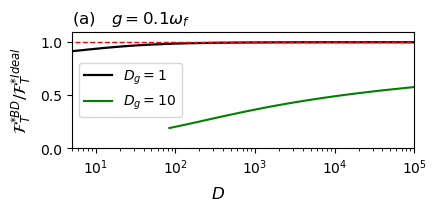

In [20]:
fig,ax = plt.subplots(1,1,figsize=(4.25,2),layout='constrained',sharex=True)
fig.supxlabel(r'$D$',fontsize='large')
ax.set_ylabel(r'$\mathcal{F}^{*BD}_T/\mathcal{F}^{*Ideal}_{T}$',fontsize='large')
ax.set_ylim([0,1.1])
ax.set_xlim([5,1e5])

refgap = wa/2 + g**2/wc + wa/2 * np.exp(-2*g**2/wc**2)
refgap = [refgap for D in Dlist]
oneline = [1 for D in Dlist]

line1_1, = ax.semilogx(D1list,idealprop1,label=r'$D_g=1$',color = 'k',lw=1.6)
#line1_8, = ax[0].semilogx(D2list,idealprop2,label=r'$D_g=5$', color = 'blue')
line1_20, = ax.semilogx(D3list,idealprop3,label=r'$D_g=10$', color = 'green')

oneline, = ax.semilogx(Dlist,oneline,ls='--',color = 'red', lw=1)

ax.set_title(r'(a)   $g=0.1\omega_f$',fontsize='large',loc='left')


ax.legend(loc='best')
plt.savefig('PeakQFItoIdealProportionA.png',bbox_inches="tight",dpi=1000)

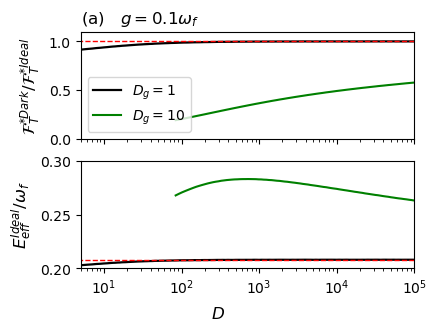

In [50]:
fig,ax = plt.subplots(2,1,figsize=(4.25,3.2),layout='constrained',sharex=True)
fig.supxlabel(r'$D$',fontsize='large')
ax[0].set_ylabel(r'$\mathcal{F}^{*Dark}_T/\mathcal{F}^{*Ideal}_{T}$',fontsize='large')
ax[0].set_ylim([0,1.1])
ax[0].set_xlim([5,1e5])

refgap = wa/2 + g**2/wc + wa/2 * np.exp(-2*g**2/wc**2)
refgap = [refgap for D in Dlist]
oneline = [1 for D in Dlist]

line1_1, = ax[0].semilogx(D1list,idealprop1,label=r'$D_g=1$',color = 'k',lw=1.6)
#line1_8, = ax[0].semilogx(D2list,idealprop2,label=r'$D_g=5$', color = 'blue')
line1_20, = ax[0].semilogx(D3list,idealprop3,label=r'$D_g=10$', color = 'green')

oneline, = ax[0].semilogx(Dlist,oneline,ls='--',color = 'red', lw=1)

ax[1].set_ylabel(r'$E_{eff}^{Ideal}/\omega_f$',fontsize='large')
ax[1].set_ylim([0.2,0.3])
ax[1].set_xlim([5,1e5])

line2_1, = ax[1].semilogx(D1list,egap1list,label=r'$D_g=1$',color = 'k',lw=1.6)
#line2_8, = ax[1].semilogx(D2list,egap2list,label=r'$D_g=5$', color = 'blue')
line2_20, = ax[1].semilogx(D3list,egap3list,label=r'$D_g=10$', color = 'green')

refline, = ax[1].semilogx(Dlist,refgap, ls='--', color = 'red', lw=1)

ax[0].set_title(r'(a)   $g=0.1\omega_f$',fontsize='large',loc='left')


ax[0].legend(loc='lower left')
plt.savefig('PeakQFItoIdealProportionA.png',bbox_inches="tight",dpi=1000)

In [21]:
Dg1 = 1
Dg2 = 5
Dg3 = 10
g=1.2
Dlist = [De[k] - 1 for k in range(len(De))]
wc = 1
wa = 0.2
normalised=True
tol = 1e-3
peakQFIaccurate1 = []
peakQFIaccurate2 = []
peakQFIaccurate3 = []

peakidealqfi1 = []
peakidealqfi2 = []
peakidealqfi3 = []

egap1list=[]
egap2list=[]
egap3list=[]

theta = 1
a, b = 0.0001, 1
X1 = 1
X2 = mode_eigs_wishart(Dg2, Dg2, normalised, beta=2, c=1.0)
X3 = mode_eigs_wishart(Dg3, Dg3, normalised, beta=2, c=1.0)

D1list = []
D2list = []
D3list = []

for k in range(len(Dlist)):
    normalised = True
    D = Dlist[k]

    if D+1>Dg1+4:
        qfi1Tstar, qfi1peak = argmax_unimodal(generate_qfi_list_darkpeak_fast, a, b, tol, wc, wa, [1], Dg1, De[k], Dmin=0, Dplu=0, Dk=0, g=g, theta=theta)
        egap1 = findEnergyGapEffective(De[k]-Dg1,qfi1Tstar)
        ideal1 = ideal_therm_qfi(De[k]-Dg1+1,egap1,[qfi1Tstar])[0]
        D1list.append(De[k]-Dg1), peakQFIaccurate1.append(qfi1peak), peakidealqfi1.append(ideal1), egap1list.append(egap1)
    else:
        pass

    if D+1>Dg2+24:
        qfi2Tstar, qfi2peak = argmax_unimodal(generate_qfi_list_darkpeak_fast, a, b, tol, wc, wa, X2, Dg2, De[k], Dmin=0, Dplu=0, Dk=0, g=g, theta=theta)
        egap2 = findEnergyGapEffective(De[k]-Dg2,qfi2Tstar)
        ideal2 = ideal_therm_qfi(De[k]-Dg2+1,egap2,[qfi2Tstar])[0]
        D2list.append(De[k]-Dg2), peakQFIaccurate2.append(qfi2peak), peakidealqfi2.append(ideal2), egap2list.append(egap2)
    else:
        pass

    if D+1>Dg3+79:
        qfi3Tstar, qfi3peak = argmax_unimodal(generate_qfi_list_darkpeak_fast, a, b, tol, wc, wa, X3, Dg3, De[k], Dmin=0, Dplu=0, Dk=0, g=g, theta=theta)
        egap3 = findEnergyGapEffective(De[k]-Dg3,qfi3Tstar)
        ideal3 = ideal_therm_qfi(De[k]-Dg3+1,egap3,[qfi3Tstar])[0]
        D3list.append(De[k]-Dg3), peakQFIaccurate3.append(qfi3peak), peakidealqfi3.append(ideal3), egap3list.append(egap3)
    else:
        pass

idealprop1 = [peakQFIaccurate1[x]/peakidealqfi1[x] for x in range(len(peakQFIaccurate1))]
idealprop2 = [peakQFIaccurate2[x]/peakidealqfi2[x] for x in range(len(peakQFIaccurate2))]
idealprop3 = [peakQFIaccurate3[x]/peakidealqfi3[x] for x in range(len(peakQFIaccurate3))]

1.5456134762834135


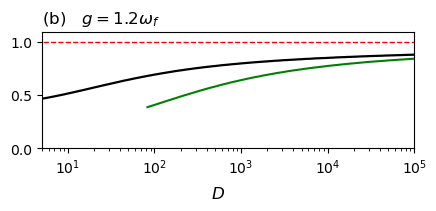

In [22]:
fig,ax = plt.subplots(1,1,figsize=(4.25,2),layout='constrained',sharex=True)
fig.supxlabel(r'$D$',fontsize='large')
#ax[0].set_ylabel(r'$\mathcal{F}^{*Dark}_T/\mathcal{F}^{*Ideal}_{T}$',fontsize=12)
ax.set_ylim([0,1.1])
ax.set_xlim([5,1e5])

refgap = wa/2 + g**2/wc + wa/2 * np.exp(-2*g**2/wc**2)
print(refgap)
refgap = [refgap for D in Dlist]
oneline = [1 for D in Dlist]

line1_1, = ax.semilogx(D1list,idealprop1,label=r'$D_g=1$',color = 'k',lw=1.6)
#line1_8, = ax[0].semilogx(D2list,idealprop2,label=r'$D_g=5$', color = 'blue')
line1_20, = ax.semilogx(D3list,idealprop3,label=r'$D_g=10$', color = 'green')

oneline, = ax.semilogx(Dlist,oneline,ls='--',color = 'red', lw=1)

ax.set_title(r'(b)   $g=1.2\omega_f$',fontsize='large',loc='left')


plt.savefig('PeakQFItoIdealProportionB.png',bbox_inches="tight",dpi=1000)

1.5456134762834135


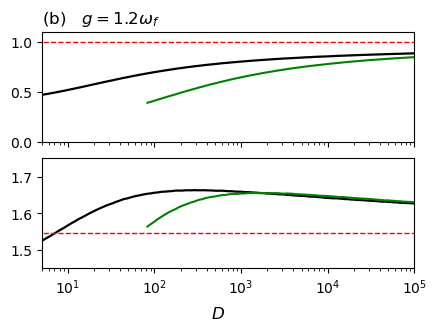

In [52]:
fig,ax = plt.subplots(2,1,figsize=(4.25,3.2),layout='constrained',sharex=True)
fig.supxlabel(r'$D$',fontsize='large')
#ax[0].set_ylabel(r'$\mathcal{F}^{*Dark}_T/\mathcal{F}^{*Ideal}_{T}$',fontsize=12)
ax[0].set_ylim([0,1.1])
ax[0].set_xlim([5,1e5])

refgap = wa/2 + g**2/wc + wa/2 * np.exp(-2*g**2/wc**2)
print(refgap)
refgap = [refgap for D in Dlist]
oneline = [1 for D in Dlist]

line1_1, = ax[0].semilogx(D1list,idealprop1,label=r'$D_g=1$',color = 'k',lw=1.6)
#line1_8, = ax[0].semilogx(D2list,idealprop2,label=r'$D_g=5$', color = 'blue')
line1_20, = ax[0].semilogx(D3list,idealprop3,label=r'$D_g=10$', color = 'green')

oneline, = ax[0].semilogx(Dlist,oneline,ls='--',color = 'red', lw=1)

#ax[1].set_ylabel(r'$E_{eff}^{Ideal}$',fontsize=12)
ax[1].set_ylim([1.45,1.75])
ax[1].set_xlim([5,1e5])

line2_1, = ax[1].semilogx(D1list,egap1list,label=r'$D_g=1$',color = 'k',lw=1.6)
#line2_8, = ax[1].semilogx(D2list,egap2list,label=r'$D_g=5$', color = 'blue')
line2_20, = ax[1].semilogx(D3list,egap3list,label=r'$D_g=10$', color = 'green')

refline, = ax[1].semilogx(Dlist,refgap, ls='--', color = 'red', lw=1)

ax[0].set_title(r'(b)   $g=1.2\omega_f$',fontsize='large',loc='left')


plt.savefig('PeakQFItoIdealProportionB.png',bbox_inches="tight",dpi=1000)

In [53]:
#STABLE MANY DARK STATES CASE
Dg=10
De1=11
De2 = 101
De3 = 1001
De4 = 10001
wa=0.25
normalised = True
minT, maxT, num = 1e-5,1e2,600
Tlist = np.geomspace(minT,maxT,num)
g = 0.1
theta = 10

qfi_acc_1 = generate_qfi_list_darkpeak_fast(wc, wa, mode_eigs_wishart(Dg, Dg, normalised, beta=2, c=1.0), Tlist, Dg, De1, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff = theta)
qfi_acc_2 = generate_qfi_list_darkpeak_fast(wc, wa, mode_eigs_wishart(Dg, Dg, normalised, beta=2, c=1.0), Tlist, Dg, De2, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff = theta)
qfi_acc_3 = generate_qfi_list_darkpeak_fast(wc, wa, mode_eigs_wishart(Dg, Dg, normalised, beta=2, c=1.0), Tlist, Dg, De3, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff = theta)

qfi1Tstar, _ = peak_xy_argmax(Tlist, qfi_acc_1)
qfi2Tstar, _ = peak_xy_argmax(Tlist, qfi_acc_2)
qfi3Tstar, _ = peak_xy_argmax(Tlist, qfi_acc_3)

egap1 = findEnergyGapEffective(De1-1,qfi1Tstar)
egap2 = findEnergyGapEffective(De2-1,qfi2Tstar)
egap3 = findEnergyGapEffective(De3-1,qfi3Tstar)

ideal1 = ideal_therm_qfi(De1-1,egap1,Tlist)
ideal2 = ideal_therm_qfi(De2-1,egap2,Tlist)
ideal3 = ideal_therm_qfi(De3-1,egap3,Tlist)

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(4,4),layout='constrained')
fig.supxlabel(r'$T$',fontsize=12)
fig.supylabel(r'$\mathcal{F}_{T2}(T)$')
ax.set_xlim([1e-3,1e2])
ax.set_ylim([1e-4,1e6])

qfiaccline1, = plt.loglog(Tlist,qfi_acc_1,label = r'$Acc_ d=10$')
qfiaccline2, = plt.loglog(Tlist,qfi_acc_2,label = r'$Acc_ d=100$')
qfiaccline3, = plt.loglog(Tlist,qfi_acc_3,label = r'$Acc_ d=1000$')

idealline1, = plt.loglog(Tlist,ideal1,label = r'$id_ d=10$')
idealline2, = plt.loglog(Tlist,ideal2,label = r'$id_ d=100$')
idealline3, = plt.loglog(Tlist,ideal3,label = r'$id_ d=1000$')

ax.legend()
plt.savefig('LargeNumberLevelsQFI.png',bbox_inches="tight")

In [14]:
def Fdark_TO_Fideal_proportion(a,b,tol,wc,wa,Xq,Dg,De,Dmin,Dplu,Dk,g,theta):
    D = De-Dg
    qfiTstar, qfipeak = argmax_unimodal(generate_qfi_list_darkpeak_fast, a, b, tol, wc, wa, Xq, Dg, De, Dmin=0, Dplu=0, Dk=0, g=g, theta=theta)
    egap = findEnergyGapEffective(De+Dg-1,qfiTstar)
    ideal = ideal_therm_qfi(De+Dg,egap,[qfiTstar])[0]
    
    #return qfipeak/ideal

    peakqfi = generate_qfi_list_theor3(wc, wa, Xq, [qfiTstar], Dg, De, Dmin=0, Dplu=0, Dk=0, gprefactor=g, Ocutoff = theta)
    return peakqfi/ideal

In [28]:
gmin,gmax,giter=0,6,120
glist = np.linspace(gmin,gmax,giter)

Dgmin,Dgmax,Dgiter=1,150,150
Dglist = np.linspace(Dgmin,Dgmax,Dgiter)

D=1000

theta = 2
a, b = 0.0001, 10
tol=1e-4

normalised=True
wc=1
wa=0.2

In [29]:
Dglist

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
       111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
       122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
       133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
       144., 145., 146., 147., 148., 149., 150.])

In [30]:
ratios = np.zeros((giter,Dgiter))

for j in range(len(Dglist)):
    print(j/len(Dglist))
    Dg = int(np.floor(Dglist[j]))
    De = Dg+D
    if Dg==1:
        Xq=[1]
    else:
        Xq = mode_eigs_wishart(Dg, Dg, normalised, beta=2, c=1.0)
    for i in range(len(glist)):
        ratios[i,j] = Fdark_TO_Fideal_proportion(a,b,tol,wc,wa,Xq,Dg,De,Dmin=0,Dplu=0,Dk=0,g=glist[i],theta=theta)

0.0


C:\Users\Tabitha\AppData\Local\Temp\ipykernel_20096\1356055639.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ratios[i,j] = Fdark_TO_Fideal_proportion(a,b,tol,wc,wa,Xq,Dg,De,Dmin=0,Dplu=0,Dk=0,g=glist[i],theta=theta)


0.006666666666666667
0.013333333333333334
0.02
0.02666666666666667
0.03333333333333333
0.04
0.04666666666666667
0.05333333333333334
0.06
0.06666666666666667
0.07333333333333333
0.08
0.08666666666666667
0.09333333333333334
0.1
0.10666666666666667
0.11333333333333333
0.12
0.12666666666666668
0.13333333333333333
0.14
0.14666666666666667
0.15333333333333332
0.16
0.16666666666666666
0.17333333333333334
0.18
0.18666666666666668
0.19333333333333333
0.2
0.20666666666666667
0.21333333333333335
0.22
0.22666666666666666
0.23333333333333334
0.24
0.24666666666666667
0.25333333333333335
0.26
0.26666666666666666
0.2733333333333333
0.28
0.2866666666666667
0.29333333333333333
0.3
0.30666666666666664
0.31333333333333335
0.32
0.32666666666666666
0.3333333333333333
0.34
0.3466666666666667
0.35333333333333333
0.36
0.36666666666666664
0.37333333333333335
0.38
0.38666666666666666
0.3933333333333333
0.4
0.4066666666666667
0.41333333333333333
0.42
0.4266666666666667
0.43333333333333335
0.44
0.44666666666666666

In [31]:
import pickle
with open('ratios2D.pkl', 'wb') as f:  # open a text file
    pickle.dump(np.flip(ratios,1), f) # serialize the list

In [32]:
with open('ratios2D.pkl', 'rb') as f:
    ratios2d = np.transpose(pickle.load(f)) # deserialize using load()

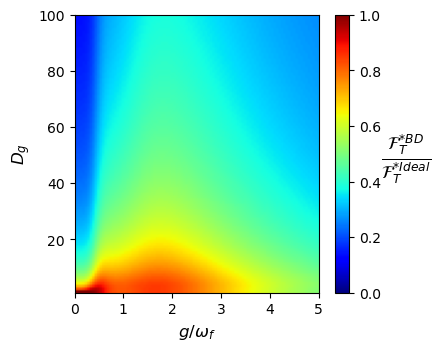

In [33]:
plt.figure(1, figsize = (4.3,3.4),layout='constrained')

norm = matplotlib.colors.Normalize(vmin=0.0, vmax=1.0)

im = plt.imshow(
    ratios2d,
    cmap='jet',
    extent=[gmin, gmax, Dgmin, Dgmax],
    aspect='auto',       # or whatever you actually want
    norm=norm            # <-- MUST be keyword
)

cbar = plt.colorbar(im)  # <-- pass the image, not the norm
plt.xlabel(r'$g/\omega_f$', fontsize='large')
plt.ylabel(r'$D_g$', fontsize='large')
cbar.set_label(r'$\frac{\mathcal{F}^{*BD}_T}{\mathcal{F}^{*Ideal}_{T}}$',
               rotation=0, fontsize=18,labelpad=18)
cbar.ax.yaxis.label.set_position((1.5, 0.58))

plt.ylim(1, 100)
plt.xlim(0,5)
plt.savefig('PeakQFI_heatmap.png',bbox_inches="tight",dpi=1000)
plt.show()

